In [84]:
#TASK 1 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [86]:
#Load Dataset
df = pd.read_csv("/Users/saivedhathota/Downloads/Housing.csv")
#Display First 10 Rows
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [88]:

#Number of Rows and Columns
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 545
Columns: 13


In [90]:

#Identify Target and Features
target = "price"      # Replace if your dataset uses a different name

X = df.drop(target, axis=1)
y = df[target]

print("Target Column:", target)
print("Feature Columns:")
print(X.columns)

Target Column: price
Feature Columns:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


In [92]:

#Check Missing Values
df.isnull().sum()   #we have no null values

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [94]:
#Task 2 – Data Cleaning

df.duplicated().sum()
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())  # we have no duplicates

Duplicate rows: 0


In [96]:
#One-Hot Encoding for Categorical Variables
df = pd.get_dummies(df, drop_first=True)
#Verify Data
df.head(10)

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0
5,10850000,7500,3,3,1,2,1,0,1,0,1,1,1,0
6,10150000,8580,4,3,4,2,1,0,0,0,1,1,1,0
7,10150000,16200,5,3,2,0,1,0,0,0,0,0,0,1
8,9870000,8100,4,1,2,2,1,1,1,0,1,1,0,0
9,9800000,5750,3,2,4,1,1,1,0,0,1,1,0,1


In [98]:

#Separate Features and Target Again
X = df.drop("price", axis=1)
y = df["price"]

In [100]:
X.head()

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,7420,4,1,2,2,1,1,1,0,1,0,0,0


In [102]:
#TASK 3 - Model Building 

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


In [104]:

#Model 1 – Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
#Evaluation
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

Linear Regression Results
MAE : 970043.4039201636
RMSE: 1324506.9600914388
R2 Score: 0.6529242642153184


In [106]:

#Model 2 – Random Forest Regressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Random Forest predictions
rf_pred = rf_model.predict(X_test)

print("Random Forest Evaluation")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

Random Forest Evaluation
MAE: 1021546.0353211008
MSE: 1961585044320.3433
RMSE: 1400565.9728553821
R2 Score: 0.611918531405699


In [108]:
#Model Comparison
comparison = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[lr_mae,rf_mae],
    "RMSE":[lr_rmse,rf_rmse],
    "R2 Score":[lr_r2,rf_r2]
})
comparison


,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


In [110]:
#Linear Regression was the best-performing model and was chosen as the final model for predicting house prices.

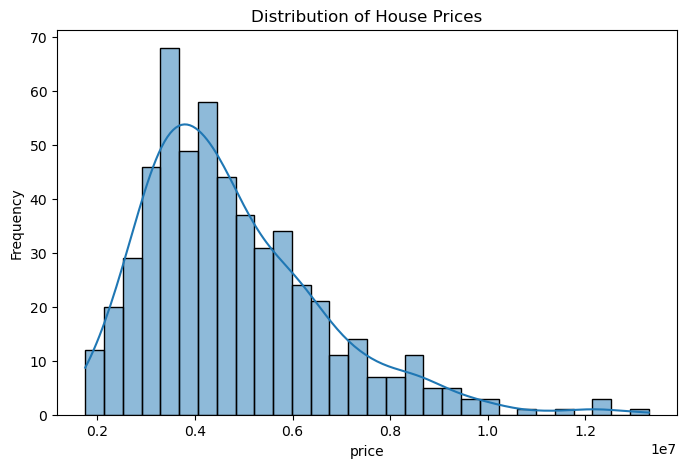

In [112]:
#TASK 4 – Visualizations

#Chart 1: House Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("price")
plt.ylabel("Frequency")
plt.show()


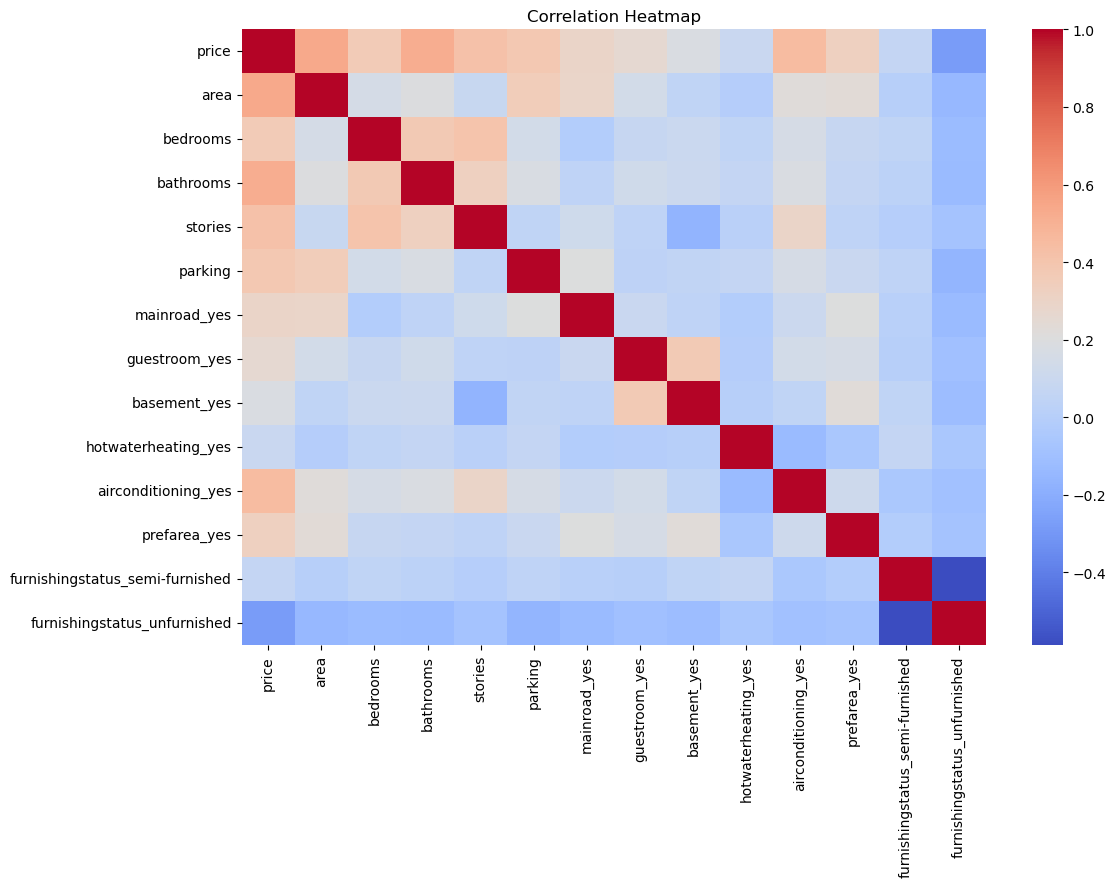

In [114]:
#Chart 2: Correlation Heatmap
plt.figure(figsize=(12,8))

corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()



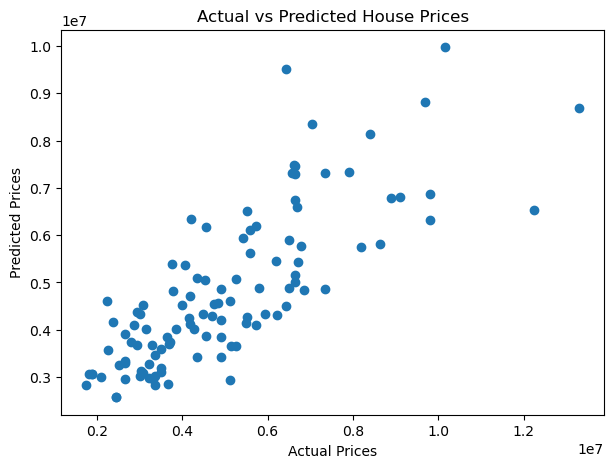

In [116]:
#Chart 3: Actual vs Predicted Prices
plt.figure(figsize=(7,5))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

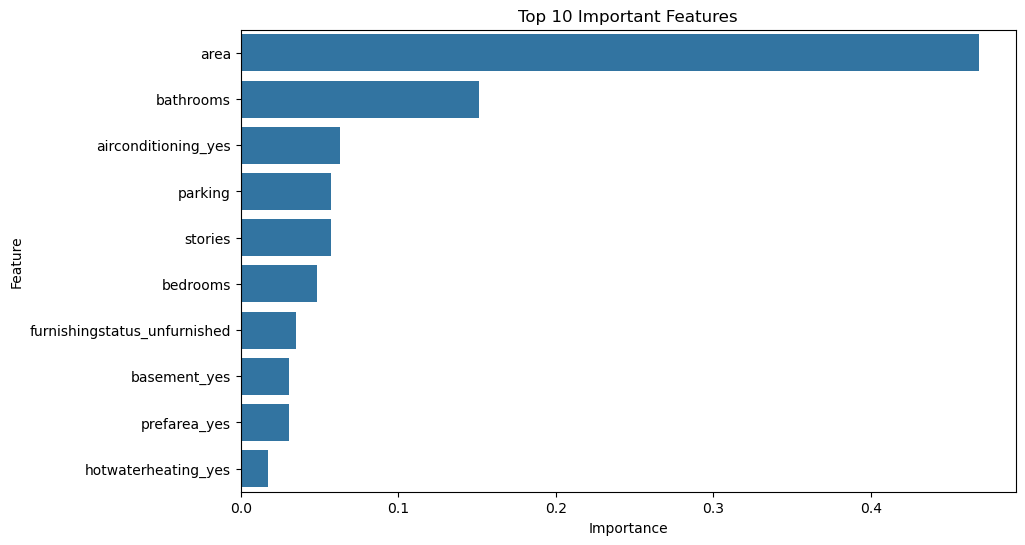

In [118]:
#Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

In [120]:
#TASK 5 – Insights & Summary:
# The analysis showed that features such as area, number of bathrooms, number of bedrooms, parking availability, and 
# amenities like air conditioning had the strongest influence on house prices. The Linear Regression model achieved an 
# R² score of approximately 0.65, which means it was able to explain about 65% of the variation in house prices and 
# provided reasonably accurate predictions. One surprising observation was that some amenities had a noticeable impact on price,
# while others contributed very little. The data also showed that larger houses with better facilities generally had higher prices. 
# Based on these findings, a real estate business should focus on property size, location-related amenities, 
# and key facilities when estimating prices and advising customers. This can help improve pricing strategies and support better buying 
# and selling decisions.
